In [96]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import scipy.signal as signal
import soundfile as sf

## Etapa 1: Caracterización Estocástica y Frecuencial

Falta...
- Definir las bandas de frecuencias con más energía concentrada.
- Definir si son ergódicas y estacionarias a tramos (definir duración) o en su totalidad.

In [97]:
audio, fs = librosa.load("audio/voz_original.wav", sr=None)

print(audio.shape)
print(fs)

(64000,)
8000


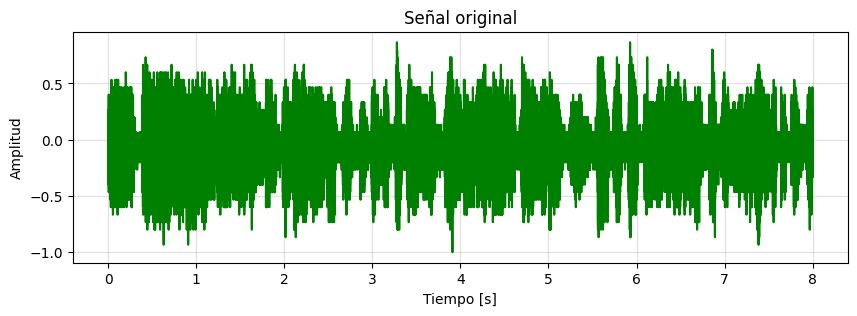

Potencia media = 0.04772217944264412


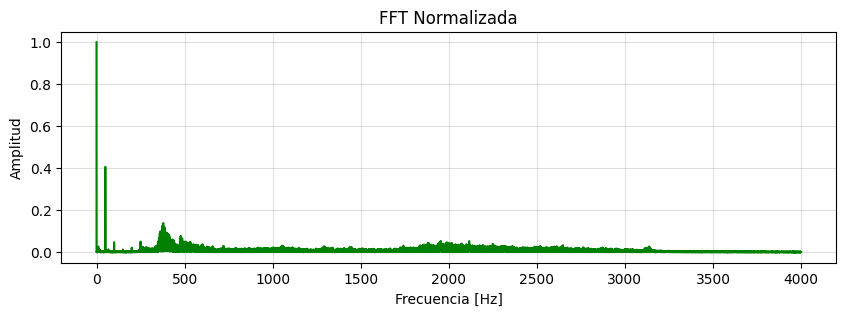

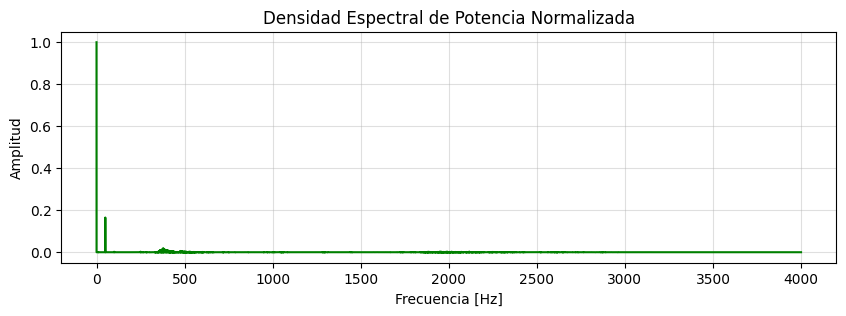

Entropía de la señal: 3.6654300421289303
Entropía de la PSD: 11.093448638916016


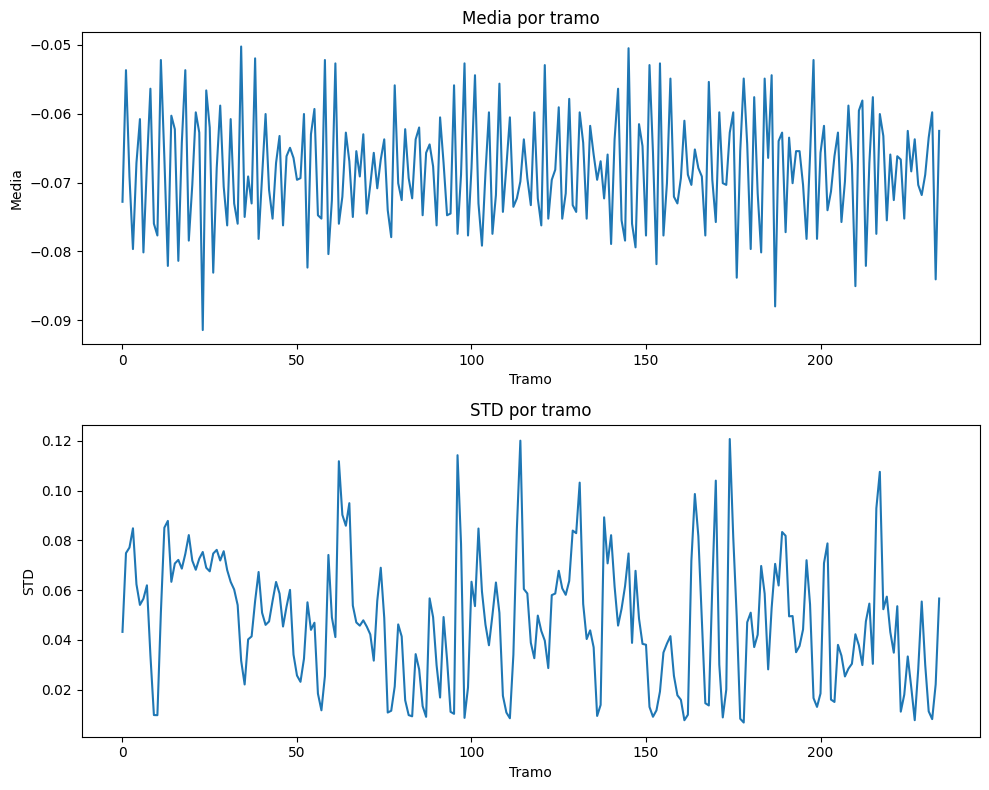

In [137]:
def graf_temp(senial, fs, figsize=(10,3), title=None):
    dom = np.arange(len(senial)) * 1/fs
    plt.figure(figsize=figsize)

    if title is None:
        plt.title("Señal original")
    else:
        plt.title(title)

    plt.ylabel("Amplitud")
    plt.xlabel("Tiempo [s]")
    plt.plot(dom, senial, c='green')
    plt.grid(True, alpha=0.4)
    plt.show()
    return dom

def graf_fft(senial, fs, figsize=(10,3), ylim=None, xticks=None):
    N = len(senial)
    
    fft = np.fft.rfft(senial, N)
    mag = np.abs(fft)
    mag /= np.max(mag)
    dom = np.fft.rfftfreq(N, 1/fs)

    plt.figure(figsize=figsize)
    plt.title("FFT Normalizada")
    plt.ylabel("Amplitud")
    if ylim is not None:
        plt.ylim(0, ylim)

    if xticks is not None:
        plt.xticks(np.arange(0, fs/2 + xticks, xticks))
    plt.xlabel("Frecuencia [Hz]")
    plt.plot(dom, mag, c='green')
    
    plt.grid(True, alpha=0.4)
    plt.show()   

def calc_fft(senial, fs):
    N = len(senial)    
    fft = np.fft.rfft(senial, N)
    mag = np.abs(fft)
    dom = np.fft.rfftfreq(N, 1/fs)  
    return dom, mag

def graf_psd(senial, fs, figsize=(10,3), ylim=None, xticks=None):
    N = len(senial)
    
    fft = np.fft.rfft(senial, N)
    mag = np.abs(fft)
    psd = mag ** 2
    psd /= np.max(psd)
    dom = np.fft.rfftfreq(N, 1/fs)

    plt.figure(figsize=figsize)
    plt.title("Densidad Espectral de Potencia Normalizada")
    plt.ylabel("Amplitud")
    if ylim is not None:
        plt.ylim(0, ylim)

    if xticks is not None:
        plt.xticks(np.arange(0, fs/2 + xticks, xticks))
    plt.xlabel("Frecuencia [Hz]")
    plt.plot(dom, psd, c='green')
    
    plt.grid(True, alpha=0.4)
    plt.show()
    return dom, psd

def calc_psd(senial, fs):
    N = len(senial)
    
    fft = np.fft.rfft(senial, N)
    mag = np.abs(fft)
    psd = mag ** 2
    dom = np.fft.rfftfreq(N, 1/fs)
    return dom, psd

def calc_potencia(senial):
    return np.mean(np.abs(senial)**2)

def calc_entropia(P):
    # Recibe histograma o PSD
    return -np.sum(P * np.log2(P))    

def obtener_tramos(senial, fs, ms, lap, start):
    N = len(senial)
    duracion_ventana = int(ms * fs/1000)
    desplazamiento = int(lap * fs/1000)
    arranque = int(start * fs/1000)

    tramos = [] # n_señales x algo 
    cant_tramos = (N - duracion_ventana)//desplazamiento + 1

    for j in range(cant_tramos):
        tramo = senial[arranque + desplazamiento * j : arranque + desplazamiento * j + duracion_ventana]
        if len(tramo) == duracion_ventana:
            tramos.append(tramo)
    return np.array(tramos)

def graf_stats(senial, fs, ms, figsize=(10,8), minmaxMedia=None, minmaxSTD=None):
    tramos = obtener_tramos(senial, fs, ms, lap=ms, start=0)
    dom = np.arange(len(tramos))
    media = np.mean(tramos, axis=1)
    #std = np.std(tramos, axis=1)
    std = np.mean(tramos**2, axis=1)

    plt.figure(figsize=figsize)
    plt.subplot(2,1,1)
    plt.title("Media por tramo")
    plt.ylabel("Media")
    plt.xlabel("Tramo")
    if minmaxMedia:
        plt.ylim(minmaxMedia[0], minmaxMedia[1])
    
    plt.plot(dom, media)

    plt.subplot(2,1,2)
    plt.title("STD por tramo")
    plt.ylabel("STD")
    plt.xlabel("Tramo")
    if minmaxSTD:
        plt.ylim(minmaxSTD[0], minmaxSTD[1])
    
    plt.plot(dom, std)
    
    plt.tight_layout()
    plt.show()

def graf_espectrograma(senial, fs, ms=20, lap=0.5, figsize=(10,4), log_scale=True, title=None):
    nperseg = int(ms * fs / 1000)
    noverlap = int(lap * nperseg)

    f, t, Sxx = signal.spectrogram(
        senial,
        fs=fs,
        window='hann',
        nperseg=nperseg,
        noverlap=noverlap,
        scaling='density',
        mode='psd'
    )

    if log_scale:
        Sxx = 10*np.log10(Sxx + 1e-12)

    plt.figure(figsize=figsize)

    plt.pcolormesh(t, f, Sxx, shading='gouraud')

    plt.xlabel("Tiempo [s]")
    plt.ylabel("Frecuencia [Hz]")

    if log_scale:
        plt.colorbar(label='PSD [dB]')

    if title:
        plt.title(title)
    else:
        plt.title('Espectrograma')

    plt.tight_layout()
    plt.show()

    return f, t, Sxx


dom_t = graf_temp(audio, fs)
print(f"Potencia media = {calc_potencia(audio)}")
graf_fft(audio, fs)
graf_psd(audio, fs)

_, psd = calc_psd(audio, fs)

hist, _ = np.histogram(audio, bins=50)
prob_hist = hist/np.sum(hist)
prob_hist = prob_hist[prob_hist > 0]

prob_psd = psd/np.sum(psd)
prob_psd = prob_psd[prob_psd > 0]
print(f"Entropía de la señal: {calc_entropia(prob_hist)}")
print(f"Entropía de la PSD: {calc_entropia(prob_psd)}")

ms = 34
graf_stats(audio, fs, ms=ms)

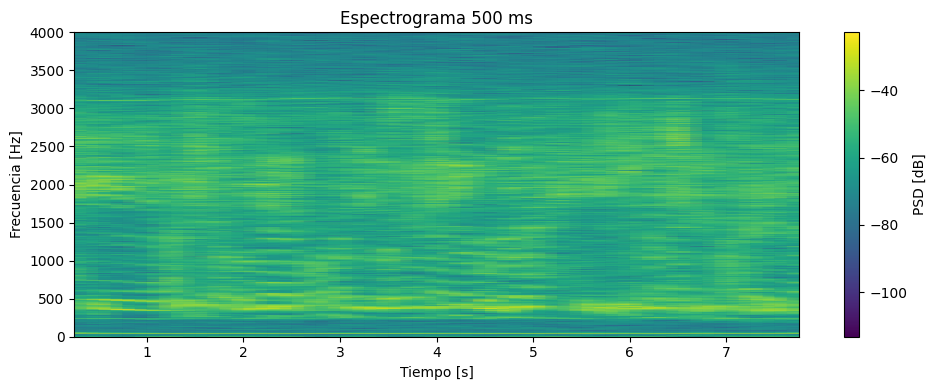

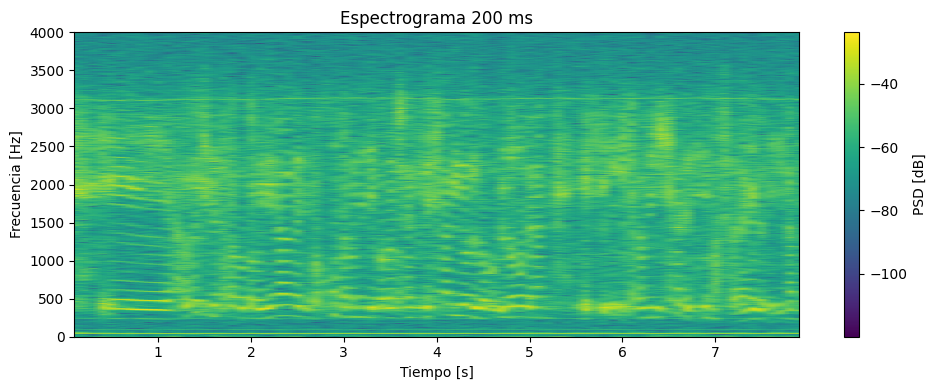

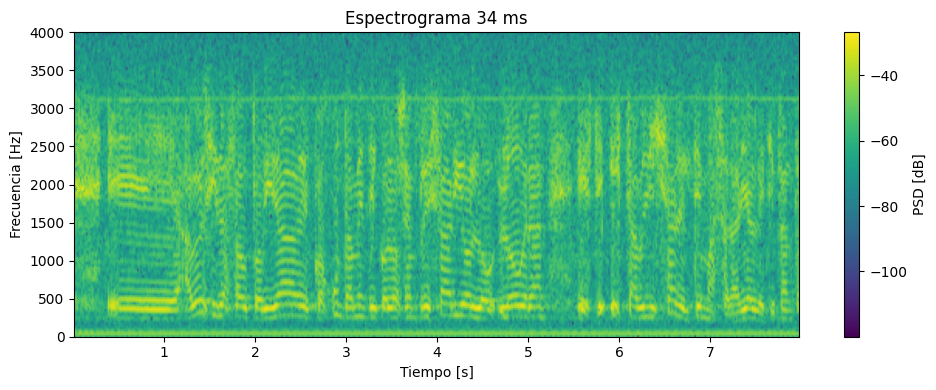

In [140]:
_ = graf_espectrograma(
    audio,
    fs,
    ms=500,
    lap=0.5,
    title='Espectrograma 500 ms'
)

_ = graf_espectrograma(
    audio,
    fs,
    ms=200,
    lap=0.5,
    title='Espectrograma 200 ms'
)

_ = graf_espectrograma(
    audio,
    fs,
    ms=34,
    lap=0.5,
    title='Espectrograma 34 ms'
)

## Etapa 2: Filtrado Digital

Falta
- Elegir y justificar el filtro seleccionado para arrastrar durante el resto del TP.

Orden: 8 972.085816583192


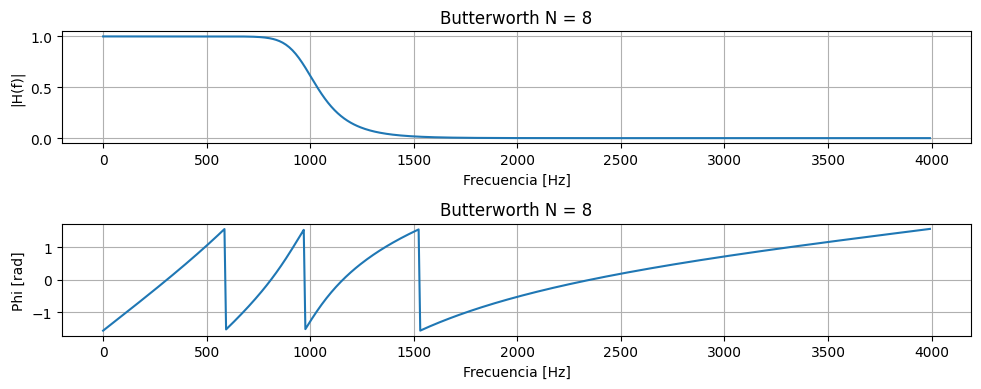

C:\Users\franc\AppData\Local\Temp\ipykernel_612\3355187295.py:38: RuntimeWarning: divide by zero encountered in divide
  phi = np.arctan(H.real/H.imag)


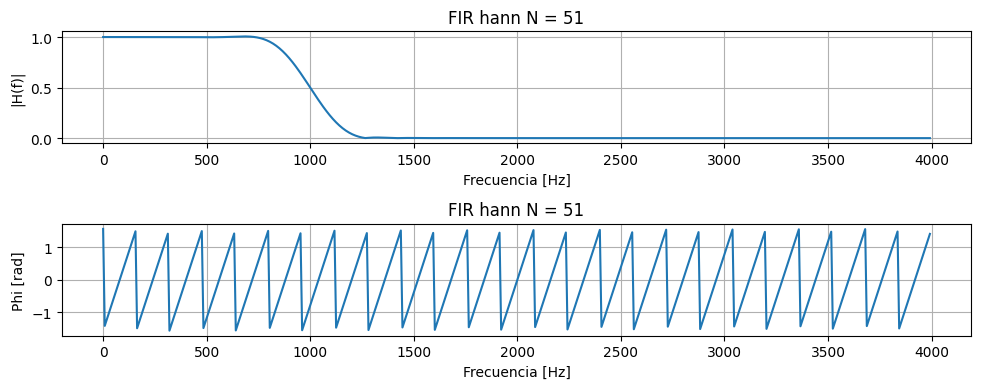

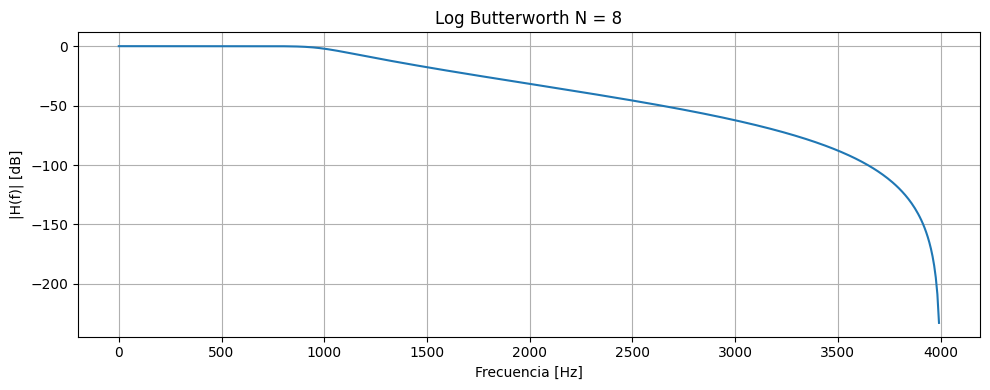

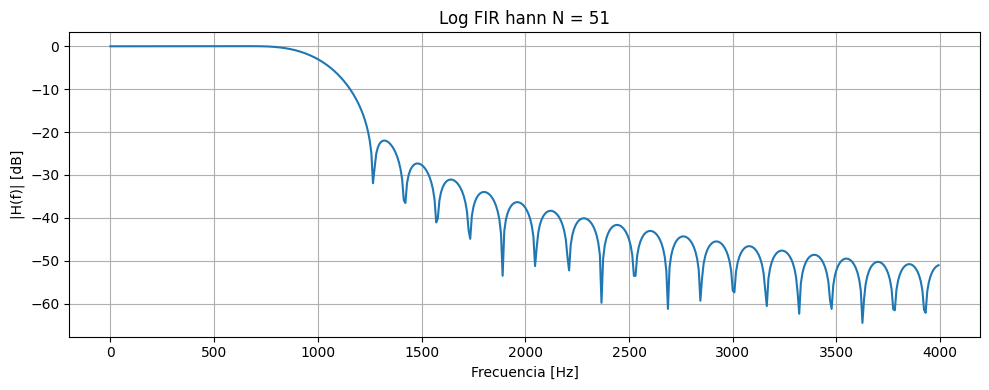

In [115]:
w_c = 1000

# IIR
eps = 100
gpass = 1
gstop = 10

# FIR
orden = 51
ventana = 'hann'


def get_iir_filter(w_c, eps, gpass, gstop):
    w_p = w_c-eps
    w_s = w_c+eps

    # Butterworth
    N_bw, wn_bw = signal.buttord(w_p, w_s, gpass, gstop, analog=False, fs=fs)
    print("Orden:", N_bw, wn_bw)

    z_bw, p_bw, k_bw = signal.butter(N_bw, wn_bw, btype = 'lowpass', analog = False, output='zpk', fs=fs)

    w, H = signal.freqz_zpk(z_bw,p_bw,k_bw,fs=fs)
    return w, H, N_bw, [z_bw, p_bw, k_bw]

def get_fir_filter(w_c, orden, ventana):
    taps = signal.firwin(orden, w_c, fs=fs, window=ventana, pass_zero=True)

    w, H = signal.freqz(taps, fs=fs)
    return w, H, taps

def graf_filter(w, H, logVisual=False, title=None, fase=False):
    h = H.copy()
    h = np.abs(h)
    if logVisual:
        h = 10*np.log10(h)

    phi = np.arctan(H.real/H.imag)

    plt.figure(figsize=(10,4))
    if fase:
        plt.subplot(2,1,1)
    plt.plot(w, h)
    plt.xlabel("Frecuencia [Hz]")
    
    if not logVisual:
        plt.ylabel("|H(f)|")
    else:
        plt.ylabel("|H(f)| [dB]")

    if title is None:
        plt.title(f"Respuesta en frecuencia")
    else:
        plt.title(title)
    plt.grid()

    if fase:
        plt.subplot(2,1,2)
        plt.plot(w, phi)
        plt.xlabel("Frecuencia [Hz]")
        plt.ylabel("Phi [rad]")
        if title is None:
            plt.title(f"Fase")
        else:
            plt.title(title)
        plt.grid()

    plt.tight_layout()
    plt.show()    
    
w_iir, H_iir, N_bw, zpk = get_iir_filter(w_c, eps, gpass, gstop)
graf_filter(w_iir, H_iir, False, title=f'Butterworth N = {N_bw}', fase=True)

w_fir, H_fir, taps = get_fir_filter(w_c, orden, ventana)
graf_filter(w_fir, H_fir, False, title=f'FIR {ventana} N = {orden}', fase=True)

graf_filter(w_iir, H_iir, True, title=f'Log Butterworth N = {N_bw}')
graf_filter(w_fir, H_fir, True, title=f'Log FIR {ventana} N = {orden}')

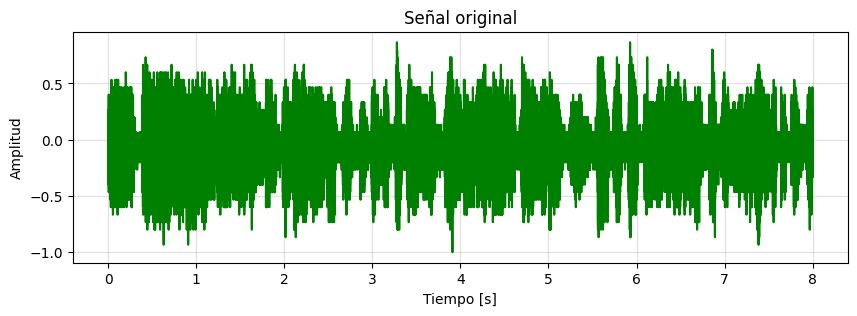

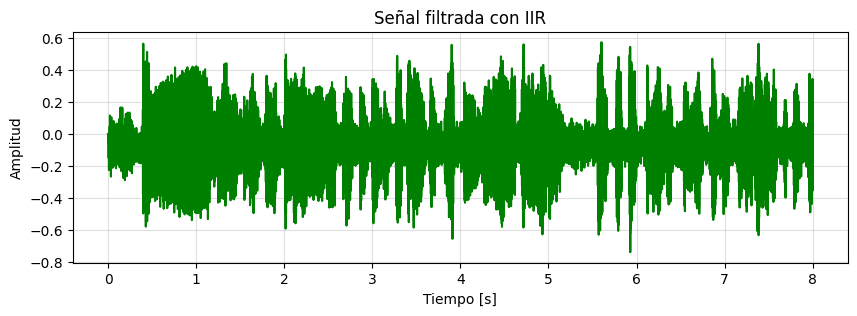

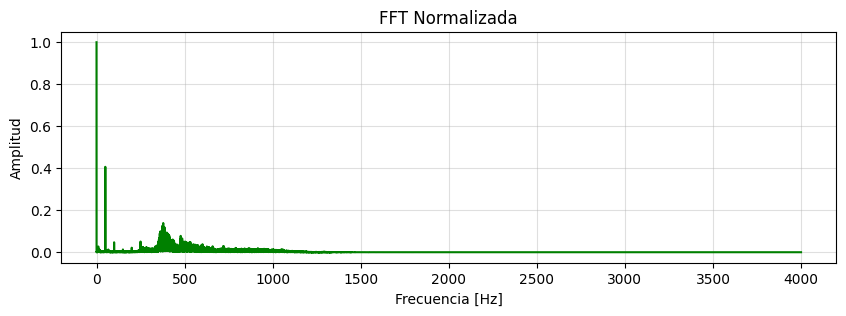

In [116]:
b, a = signal.zpk2tf(zpk[0], zpk[1], zpk[2])
audio_filtrado_iir = signal.lfilter(b, a, audio)

graf_temp(audio, fs)
graf_temp(audio_filtrado_iir, fs, title='Señal filtrada con IIR')
graf_fft(audio_filtrado_iir, fs)

sf.write("audio/voz_original_recIIR.wav", audio_filtrado_iir, fs)

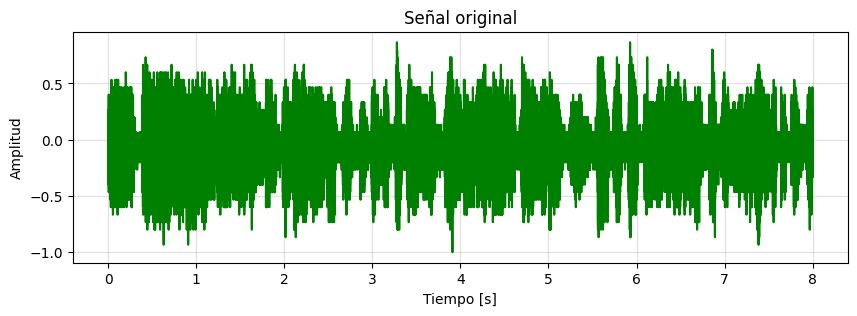

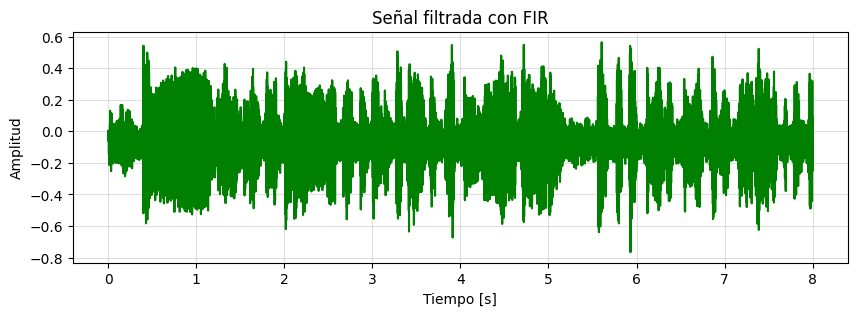

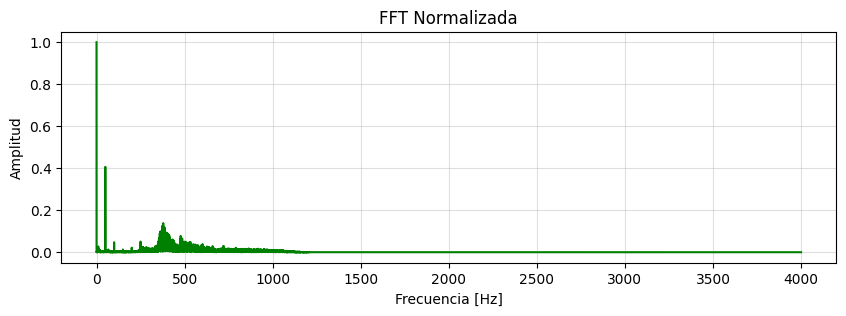

In [117]:
audio_filtrado_fir = signal.lfilter(taps, [1], audio)

graf_temp(audio, fs)
graf_temp(audio_filtrado_fir, fs, title='Señal filtrada con FIR')
graf_fft(audio_filtrado_fir, fs)

sf.write("audio/voz_original_recFIR.wav", audio_filtrado_fir, fs)

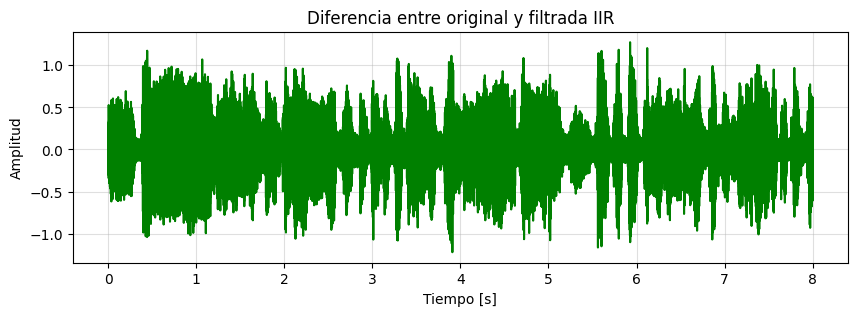

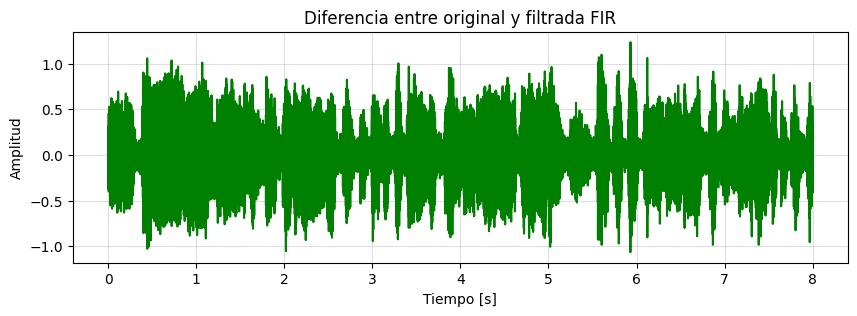

In [134]:
diff_iir = audio - audio_filtrado_iir
diff_fir = audio - audio_filtrado_fir

_ = graf_temp(diff_iir, fs, title='Diferencia entre original y filtrada IIR')
_ = graf_temp(diff_fir, fs, title='Diferencia entre original y filtrada FIR')

In [119]:
audio_filtrado = audio_filtrado_iir.copy()

## Etapa 3: Modelado y Compresión mediante Predicción Lineal (LPC)

Falta
- Justificar ms de ventana.
- Elegir una ventana para mitigar el spectral leakage.

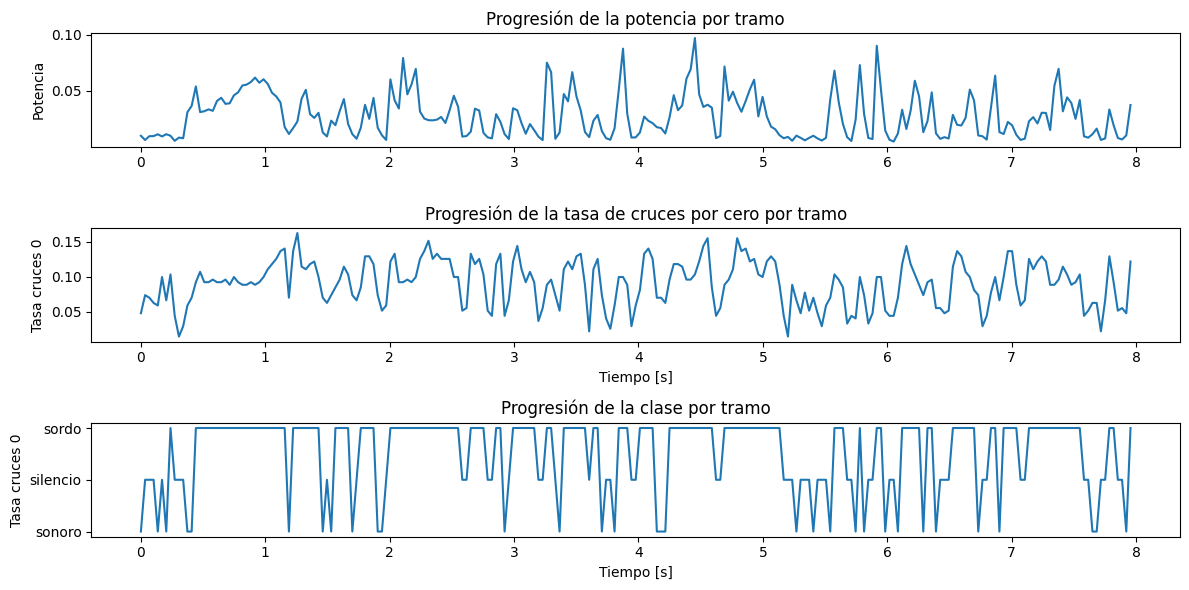

In [166]:
def det_voiced(tramo, UMBRAL_SILENCIO, UMBRAL_ZCR):

    potencia = np.mean(tramo**2)

    signos = np.sign(tramo)

    zcr = np.sum(
        signos[1:] != signos[:-1]
    ) / (len(tramo)-1)

    if potencia < UMBRAL_SILENCIO:
        clase = "silencio"
    elif zcr < UMBRAL_ZCR:
        clase = "sonoro"
    else:
        clase = "sordo"

    return potencia, zcr, clase

tramos = obtener_tramos(audio_filtrado, fs, ms, ms, 0)


potencias = []
zcrs = []
clases = []
UMBRAL_SILENCIO = 0.01
UMBRAL_ZCR = 0.075
for t in tramos:
    p, z, c = det_voiced(t, UMBRAL_SILENCIO, UMBRAL_ZCR)
    potencias.append(p)
    zcrs.append(z)
    clases.append(c)

aux_dom = np.arange(len(potencias)) * ms / 1000

plt.figure(figsize=(12,6))
plt.subplot(3,1,1)
plt.title("Progresión de la potencia por tramo")
plt.ylabel("Potencia")
plt.plot(aux_dom, potencias)

plt.subplot(3,1,2)
plt.title("Progresión de la tasa de cruces por cero por tramo")
plt.plot(aux_dom, zcrs)
plt.ylabel("Tasa cruces 0")
plt.xlabel("Tiempo [s]")

plt.subplot(3,1,3)
plt.title("Progresión de la clase por tramo")
plt.plot(aux_dom, clases)
plt.ylabel("Tasa cruces 0")
plt.xlabel("Tiempo [s]")
plt.tight_layout()
plt.show()